In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import xarray as xr
import itertools
import scipy as sp

import sys
import pathlib
sys.path.append(str(pathlib.Path.cwd().parent.parent))
import ISRUtilities as isru
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAUnits'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _avalCoord(session,regs=None,when='sleep.*#0',threshold=30):

    R = fma.regions.regions(session,phases=when,states='sws',events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]
    reg_pair_idx = [list(p) for p in itertools.combinations(range(len(regs)),2)] # make region pairs preserving order
    #reg_pair_idx = reg_pair_idx + [p[::-1] for p in reg_pair_idx] # add reverse
    reg_pairs = [f'{regs[rp[0]]}-{regs[rp[1]]}' for rp in reg_pair_idx]

    isa = {True: R.eventIntervals('slownr',duration=1200), False: R.eventIntervals([['sws','/slownr']],duration=1200)}

    lags = np.linspace(-0.2,0.2,51)
    overlap = np.full((2,len(reg_pair_idx),len(lags)),np.nan)

    for k, a in enumerate([True,False]): # True: ISA, False: nISA
        size, intervals, size_t = R.avalanches(regs=regs,when=isa[a],thresh=threshold,step=3)
        for i, rp in enumerate(reg_pair_idx):
            for j, lag in enumerate(lags):
                inters = fma.general.intersectIntervals((intervals[regs[rp[0]]], intervals[regs[rp[1]]]+lag))
                overlap[k,i,j] = np.diff(inters).sum()

    overlap = xr.DataArray(overlap,dims=['isa','reg','lag'],coords={'isa': [True,False],'reg': reg_pairs, 'lag': lags, 'rat': int(R.rat), 'base': R.basename})

    return overlap

In [3]:
# test one session
session = fma.data.readBatchFile(batch_file)[0][22]
print(f'session: {session}')
xdata = _avalCoord(session,threshold=70,when='sleep.*#0')

session: /mnt/hubel-data-140/karadoc/Rat004_20240310/Rat004_20240310.xml


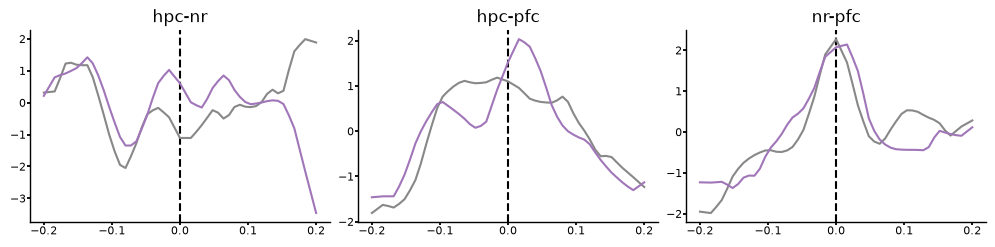

In [4]:
fig, ax = fma.plotting.makeFigure(size=(25,6),n=(1,len(xdata.reg)))
for i, r in enumerate(xdata.reg.values):
    ax[i].axvline(0,ls='--',color='k')

    data = sp.stats.zscore(xdata.sel(isa=False,reg=r).values)
    ax[i].plot(xdata.lag,data,color=isru.paperColors('shuffle'))
    data = sp.stats.zscore(xdata.sel(isa=True,reg=r).values)
    ax[i].plot(xdata.lag,data,color=isru.paperColors('nr'))

    ax[i].set(title=r)

run batch

In [8]:
overlap_cat = []
for i in range(2):
    overlap = fma.data.runBatch(batch_file,_avalCoord,kwargs={'threshold': 85, 'when': f'sleep.*#{i}'},parallel=True)
    overlap_cat.append(xr.concat([d for d in overlap if d is not None],dim='base',join='outer',coords='all'))
overlap_cat = xr.concat(overlap_cat,dim='sleep',join='inner',coords='all')
t_max = overlap_cat.values.argmax(axis=-1)
t_max = xr.DataArray(overlap_cat.lag.values[t_max],coords=[overlap_cat.sleep,overlap_cat.rat,overlap_cat.isa,overlap_cat.reg])


Starting Batch, 2026-08-13 14:50:55.990679 

Error in session /mnt/hubel-data-139/karadoc/Rat004_20240303/Rat004_20240303.xml (17)
index 0 is out of bounds for axis 0 with size 0
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230819/Rat002_20230819.xml (38)
index 0 is out of bounds for axis 0 with size 0
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230821/Rat002_20230821.xml (40)
index 0

/tmp/ipykernel_2448002/1331150854.py:5: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'base' ('base',) The recommendation is to set join explicitly for this case.
  overlap_catttt = xr.concat(overlap_cat,dim='sleep')


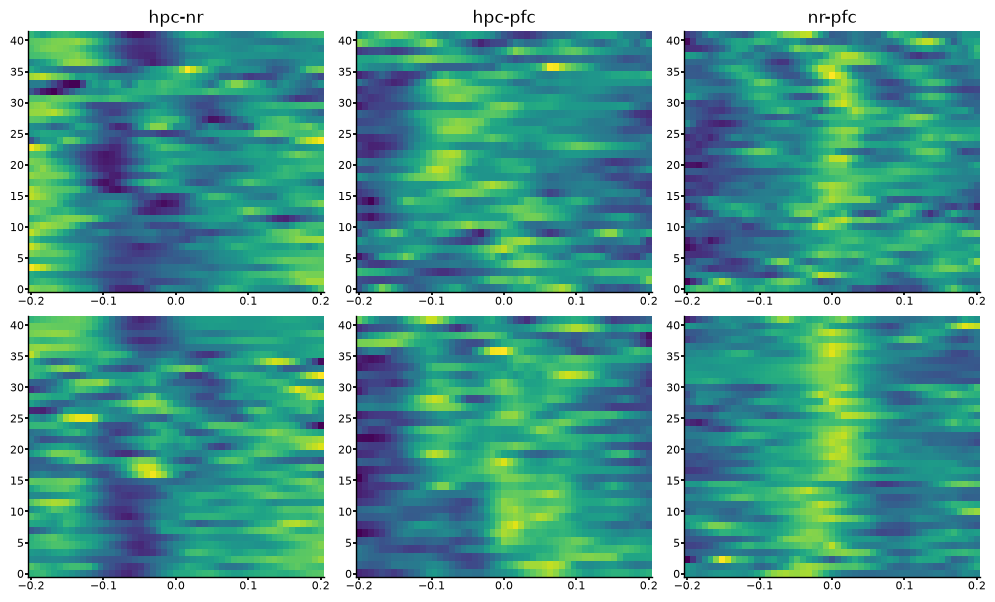

In [37]:
regs = ['hpc-nr','hpc-pfc','nr-pfc']
fig, ax = fma.plotting.makeFigure(size=(25,15),n=(2,len(regs)))
for i, r in enumerate(regs):
    o = overlap_cat.sel(reg=r,sleep=0)

    fma.plotting.plotColorMap(o.sel(isa=False),x=o.lag,ax=ax[0,i],zscore=1,omitnan=1)
    fma.plotting.plotColorMap(o.sel(isa=True),x=o.lag,ax=ax[1,i],zscore=1,omitnan=1)
    ax[0,i].set(title=r)

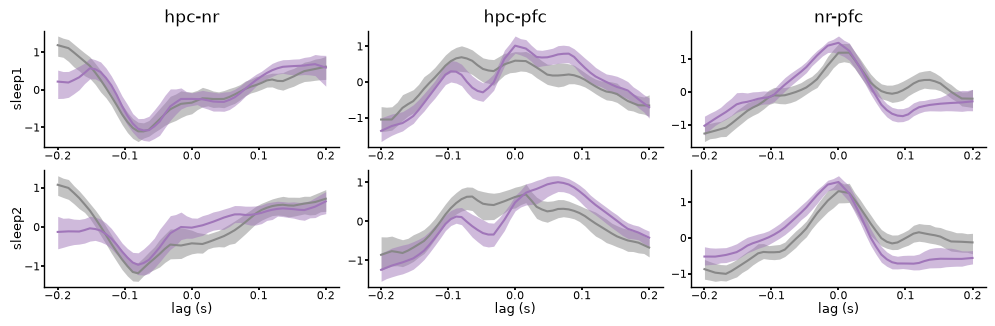

In [28]:
fig, ax = fma.plotting.makeFigure(size=(25,8),n=(2,len(regs)))
for i, r in enumerate(regs):
    for j in range(2):
        o = overlap_cat.sel(reg=r,sleep=j)
        fma.plotting.semPlot(o.lag,o.sel(isa=False),zscore=2,color=isru.paperColors('shuffle'),ax=ax[j,i])
        fma.plotting.semPlot(o.lag,o.sel(isa=True),zscore=2,color=isru.paperColors('nr'),ax=ax[j,i])
    ax[0,i].set(title=r), ax[1,i].set(xlabel='lag (s)')
ax[0,0].set(ylabel='sleep1'), ax[1,0].set(ylabel='sleep2');

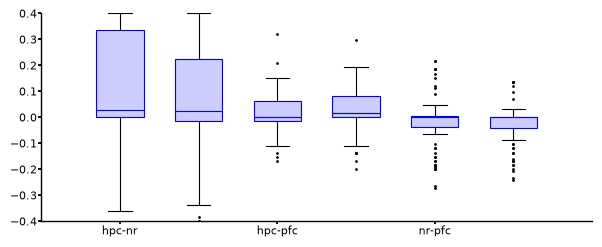

In [33]:
fig, ax = fma.plotting.makeFigure(size=(15,6))
data = []
for s in range(2):
    data.append([])
    for i, r0 in enumerate(regs):
        t = t_max.sel(isa=True,reg=r0,sleep=s).values - t_max.sel(isa=False,reg=r0).values
        data[-1].append(t) #t[p_val.sel(isa=True,reg=r0).values < 0.05]
ax[0].set(ylim=(-0.4,0.4))

x = np.arange(3)
fma.plotting.boxPlot(data[1],x=x+0.5,ax=ax[0])
fma.plotting.boxPlot(data[0],x=x,ax=ax[0],label=regs)

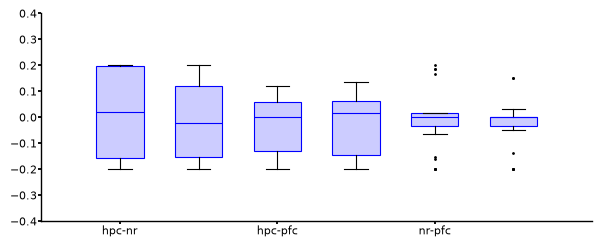

In [34]:
fig, ax = fma.plotting.makeFigure(size=(15,6))
data = []
for s in range(2):
    data.append([])
    for i, r0 in enumerate(regs):
        t = t_max.sel(isa=True,reg=r0,sleep=s).values
        data[-1].append(t)
ax[0].set(ylim=(-0.4,0.4))

x = np.arange(3)
fma.plotting.boxPlot(data[1],x=x+0.5,ax=ax[0])
fma.plotting.boxPlot(data[0],x=x,ax=ax[0],label=regs)